## Putting it all together for Training
Pipeline: Preprocessing -> Feature extraction -> spike encoding ->training

In [2]:
from pipeline_functions import *

import numpy as np

import snntorch.spikeplot as splt
import snntorch as snn
from snntorch import functional as SF

import matplotlib.pyplot as plt

import torch
import torch.nn as nn

#sets seed for random to 42
torch.manual_seed(42) 

# sets device for tensors and model
if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

Using device: cpu


### Preprocessing

In [3]:
## preprocessing function to be inputted
X, y = [],[]

has_file = True #only set to false if you dont have the numpy array file and need to reload all the subjects

if has_file==True:
    X = np.load("X.npy", mmap_mode='r') # mmap does not load entire ds at once to keep memory available
    y = np.load("y.npy")
else:
    X = np.empty((8, 307, 99000), dtype=np.float32)
    y = np.empty((99000,), dtype=np.float32)
    # loads data for all 55 subjects and preprocesses it
    x_idx, y_idx = 0, 0
    for num_subj in range(55): #WARNING, very long!
        file_name = f"C:/Users/crims/Desktop/Senior Design Code/datasets/Won2022_BIDS/.mat_files/s{num_subj+1:02d}.mat"
        # print(f"Loading {file_name}")
        X_subj, y_subj, time = fn_preprocess.preprocess_training(file_name)

        epoch_num = X_subj.shape[2]
        y_len = y_subj.shape[0]
        
        X[:, :, x_idx:x_idx+epoch_num] = X_subj.astype(np.float32, copy=False)
        y[y_idx:y_idx+y_len] = y_subj.astype(np.float32, copy=False)

        x_idx += epoch_num
        y_idx += y_len

        print(f"Subject {num_subj+1} loaded. Size: {X_subj.shape}")
    
    assert x_idx == X.shape[2]
    assert y_idx == y.shape[0]

    # saves as numpy after done
    np.save("X.npy", X)
    np.save("y.npy", y)
    print("Data successfully saved")

    del X
    X = np.load("X.npy", mmap_mode='r') # mmap does not load entire ds at once to keep memory available

(8, 307, 99000)
float32
(99000,)
(16500, 307)
(82500, 307)


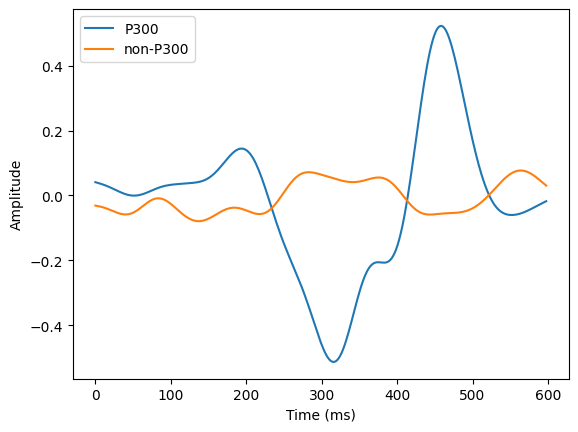

In [24]:
print(X.shape)
print(X.dtype)
print(y.shape)
p300_trials = X[2, :, y == 1]
non_p300_trials = X[2, :, y == 0]
print(p300_trials.shape)
print(non_p300_trials.shape)

avg_P300 = p300_trials.mean(axis=0)
avg_non_P300 = non_p300_trials.mean(axis=0)

time = np.arange(avg_P300.shape[0]) / 512 * 1000

plt.plot(time, avg_P300, label='P300')
plt.plot(time, avg_non_P300, label='non-P300')
plt.xlabel("Time (ms)")
plt.ylabel("Amplitude")
plt.legend()



### Feature Extraction

In [ ]:
## feature extraction
fe_files = False
X_norm, fe_X = [], []
if fe_files:
    print(f"X shape: {X.shape}")
    X_norm = np.load("X_norm.npy", mmap_mode='r')
    fe_X = np.load("fe_X_P300.npy")
    fe_norm = np.load("fe_norm_P300.npy")
    print(f"Shape after normalization: {X_norm.shape}")
    print(f"Features array shape: {fe_X.shape}")
else:
    times = fn_preprocess.find_times('C:/Users/crims/Desktop/Senior Design Code/datasets/Won2022_BIDS/.mat_files/s01.mat')
    X_sel_norm, fe_sel_X, fe_sel_norm = fn_feature_extraction.extractFeatures(X, times)
    np.save("X_sel_norm.npy", X_sel_norm)
    np.save("fe_X_sel_P300.npy", fe_sel_X)
    np.save("fe_norm_sel_P300.npy", fe_sel_norm)
    print("Data successfully saved")


Times min: 0.0
Times max: 597.65625
Times shape: (307,)
X shape: (99000, 8, 307)
Shape after normalization: (99000, 8, 307)
Features array shape: (99000, 40)
Reshaped tensor for SNN input: (99000, 2456)


In [27]:
np.save("X_sel_norm.npy", X_sel_norm)
np.save("fe_X_sel_P300.npy", fe_sel_X)
np.save("fe_norm_sel_P300.npy", fe_sel_norm)
print("Data successfully saved")

Data successfully saved


In [5]:
# only pz electrode, uncomment to change to only have that electrode, will also have to change initial layer in module creation
# X_norm = X_norm[:, 12, :]
# print(X_norm.shape)

### Spike Encoding

This is a first place we can alter hyperparameters for results <br>
We can change:
- T_ms
- dt_ms
- r_min
- r_max

In [30]:
T_ms = 75
dt_ms = 1
r_min = 150
r_max = 300
encoded_X, r_hz = spike_encoding.deterministic_rate(fe_X, T_ms=T_ms, dt_ms=dt_ms, r_min=r_min, r_max=r_max)
print(encoded_X.shape)
print(r_hz.shape)

(99000, 160, 75)
(99000, 160)


In [31]:
print(encoded_X[1, 1, :])
print(r_hz[1, 1])
print(encoded_X.mean())

[0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 0
 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0 0 1 0 0 0 0 1 0 0
 0]
225.09024
0.20429695538720538


### Create tensors and dataloaders from the data

Hyperparameter to tune
- batch_size

In [32]:
batch_size = 128

# in order (trials, time_steps, features) by swapping last two dimensions
encoded_X = np.moveaxis(encoded_X, source=-1, destination=1)
print(encoded_X.shape)

train_loader, val_loader, test_loader, class_weights = train.prepare_training_data(encoded_X, y, batch_size=batch_size, balanced=False)

(99000, 75, 160)
Train size: 69300, Val size: 14850, Test size: 14850
Training Class Counts:  tensor([57695, 11605])
Training Class Weights: tensor([0.3349, 1.6651])


### Module Creation

Hyperparameters:
- hidden_layer
- betas for each LIF layer
- thresholds for each LIF layer (**important!!)

In [33]:
# determined from feature extraction
num_features = encoded_X.shape[2] # * encoded_X.shape[3]
print(num_features)

#tunable
hidden_layer = 128
betas = [0.9, 0.9]
thresholds = [1, 2.1]

snn = SNNModule.createSNN(num_features, hidden_layer=hidden_layer, betas=betas, thresholds=thresholds)

160


### Training Hyperparameters

Tunable:
- num_epochs (for hyperparameter tuning, keep low to find other parameters optimal, then increase once found for real training)
- lr (learning rate: How fast the model changes)
- criterion: loss function to use, changed to Cross Entropy loss to calculate for membrane potential instead of spikes (hopefully more stable)
- loss style: calculate loss with 'spk' or 'mem', for spike output or membrane potential output
- optimizer: method to change weights, can use Adam, SGD w/ momentum, and others. Adam is usually the best but others can be checked
- weight_decay and more: there are other parameters we can change if these dont give good results

In [ ]:
num_epochs = 3
lr = 1e-3

criterion = nn.CrossEntropyLoss(weight=class_weights)
loss_style='spk'
optimizer = torch.optim.Adam(snn.parameters(), lr=lr)

update_every = 2 # will not change results, just prints updates divisible by this number

history = train.train(model=snn, num_epochs=num_epochs, train_loader=train_loader, val_loader=val_loader,
                      criterion=criterion, optimizer=optimizer, device=device,loss_style=loss_style, update_every=update_every, batch_first=True)

Epoch 1: Training Loss: 0.7152, Training Accuracy: 43.65%, Validation Loss: 0.6798, Validation Accuracy: 86.67%
Avg output spike rate: 0.4900
Avg output membrane max: 3.2470
Predictions for each class: tensor([135,   0])
Epoch 3: Training Loss: 0.7277, Training Accuracy: 41.43%, Validation Loss: 0.6820, Validation Accuracy: 86.67%
Avg output spike rate: 0.4900
Avg output membrane max: 3.2152
Predictions for each class: tensor([135,   0])
Epoch 5: Training Loss: 0.7251, Training Accuracy: 29.68%, Validation Loss: 0.6843, Validation Accuracy: 86.67%
Avg output spike rate: 0.4800
Avg output membrane max: 3.0706
Predictions for each class: tensor([135,   0])
Epoch 7: Training Loss: 0.7120, Training Accuracy: 69.68%, Validation Loss: 0.6814, Validation Accuracy: 86.67%
Avg output spike rate: 0.4800
Avg output membrane max: 3.1273
Predictions for each class: tensor([135,   0])
Epoch 9: Training Loss: 0.6934, Training Accuracy: 82.38%, Validation Loss: 0.6717, Validation Accuracy: 86.67%
Avg 

In [11]:
# small subset to check if it works

# idx0 = np.where(y == 0)[0][:5]
# idx1 = np.where(y == 1)[0][:5]

# idx = np.concatenate([idx0, idx1])

# small_X = torch.from_numpy(encoded_X[idx]).float()
# small_y = torch.from_numpy(y[idx])

# from torch.utils.data import DataLoader, random_split, TensorDataset, WeightedRandomSampler
# small_dataset = TensorDataset(small_X, small_y)
# small_loader = DataLoader(small_dataset, batch_size=10, shuffle=True)
# history = train.train(
#     model=snn,
#     num_epochs=300,
#     train_loader=small_loader,
#     val_loader=small_loader,
#     criterion=criterion,
#     optimizer=optimizer,
#     device=device,
#     batch_first=True
# )

# this works and brings accuracy up to 100%

In [ ]:
# testing on unseen test set
test_loss, test_acc, test_spk_rate, test_mem_max, test_pred_counts = train.validate_snn(snn, test_loader, criterion, 
                                                                                        device=device, loss_style='spk', batch_first=True)
print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc*100:.2f}%")
print(f"Avg output spike rate: {test_spk_rate:.4f}")
print(f"Avg output membrane max: {test_mem_max:.4f}")
print(f"Predictions for each class: {test_pred_counts}")

In [ ]:
# one example of a test spike output
data, targets = next(iter(test_loader))
print(data.shape)
data, targets = data.to(device), targets.to(device)
with torch.no_grad():
    snn.eval()
    spk_rec, mem_rec = snn(data, batch_first=True)

spk_rec = spk_rec[:, 4, :]
mem_rec = mem_rec[:, 4, :]
#print(mem_rec)
print(spk_rec)
#print(mem_rec.shape)
print("Shape of output:", spk_rec.shape)
print("Sum of spikes for each output:", spk_rec.sum(axis=0))

torch.Size([128, 100, 32, 307])
tensor([[0., 0.],
        [0., 0.],
        [0., 0.],
        [0., 0.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1.],
        [1., 0.],
        [0., 1

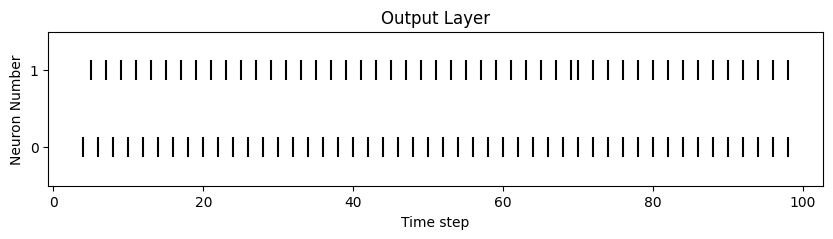

In [13]:
fig = plt.figure(facecolor="w", figsize=(10, 2))
ax = fig.add_subplot(111)

#  s: size of scatter points; c: color of scatter points
splt.raster(spk_rec, ax, s=200, c="black", marker='|')
plt.yticks([0, 1], ['0', '1'])
ax.set_ylim(-0.5, 1.5)
plt.title("Output Layer")
plt.xlabel("Time step")
plt.ylabel("Neuron Number")
plt.show()

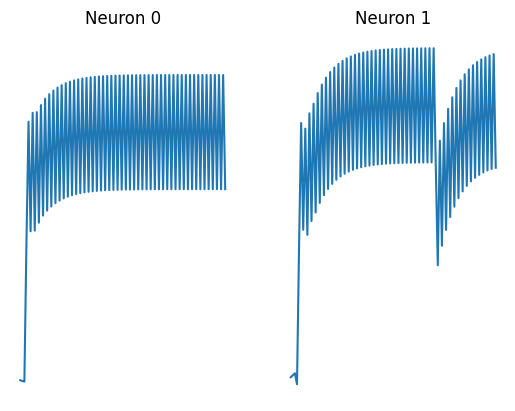

In [14]:
splt.traces(mem_rec, dim=(1, 2), titles=['Neuron 0', 'Neuron 1'])

### Final Decision

Here we can save our weight parameters to be loaded in

In [15]:
model_weights = snn.state_dict()

weights_file_path = 'model_weights/snn_weights.pth'

torch.save(model_weights, weights_file_path)